In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"
darien_path = os.path.join(base_path, "DARIEN")
modele_path = {
    "tok2vec_enrichi": os.path.join(base_path, "resultats_tok2vec_enrichi"),
    "tok2vec_quaero_fusioné": os.path.join(base_path, "resultats_tok2vec_quaero_fusioné"),
    "tok2vec_initial": os.path.join(base_path, "resultats_tok2vec_initial")
}

In [ ]:
fichiers = {
    "REF": {
        "spacy": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/REF/DARIEN_Le-voleur_REF.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_REF_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_REF_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_REF_tok2vec_initial.json",
    },
    "TESSERACT": {
        "spacy": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_initial.json",
    },
    "KRAKEN": {
        "spacy": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_spacy-lg-3.7.5.json",
        "flair": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_flair-0.13.1.json",
        "camembert": f"{darien_path}/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_camembert-4.41.1.json",
        "tok2vec_enrichi": f"{modele_path['tok2vec_enrichi']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_enrichi.json",
        "tok2vec_quaero_fusioné": f"{modele_path['tok2vec_quaero_fusioné']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_quaero_fusioné.json",
        "tok2vec_initial": f"{modele_path['tok2vec_initial']}/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_initial.json",
    }
}

In [ ]:
def normaliser_label(label):
    if label.startswith("LOC"):
        return "LOC"
    return label

In [ ]:
def compter_par_type(json_path):
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if isinstance(data, dict):
                entites = data.values()
            elif isinstance(data, list):
                entites = data
            else:
                return Counter()

        cpt = Counter()
        for ent in entites:
            label = ent.get("label", "")
            if isinstance(label, list):
                for l in label:
                    cpt[normaliser_label(l)] += 1
            elif isinstance(label, str):
                for l in label.split(","):
                    cpt[normaliser_label(l.strip())] += 1
        return cpt
    except Exception as e:
        print(f"Erreur avec {json_path} : {e}")
        return Counter()

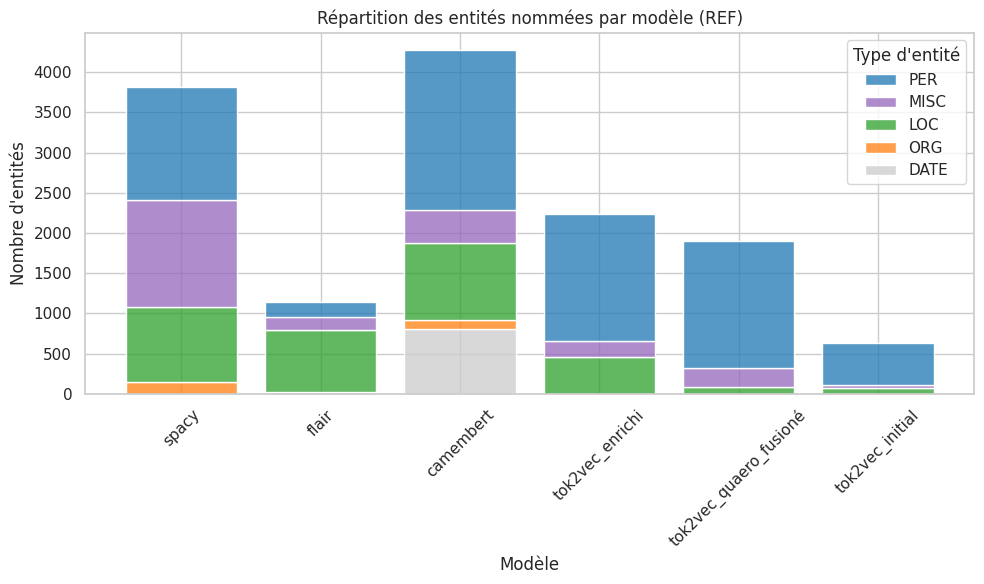

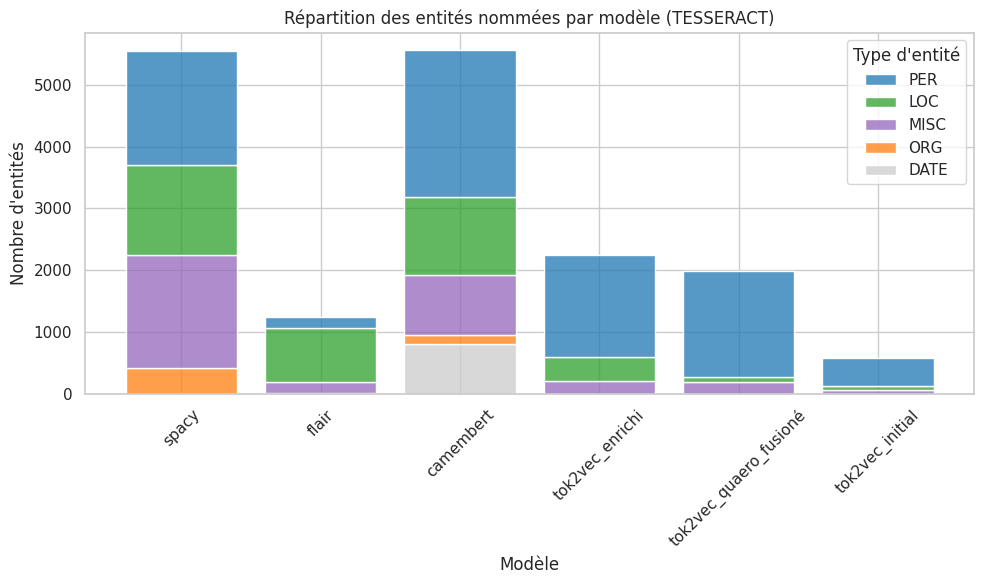

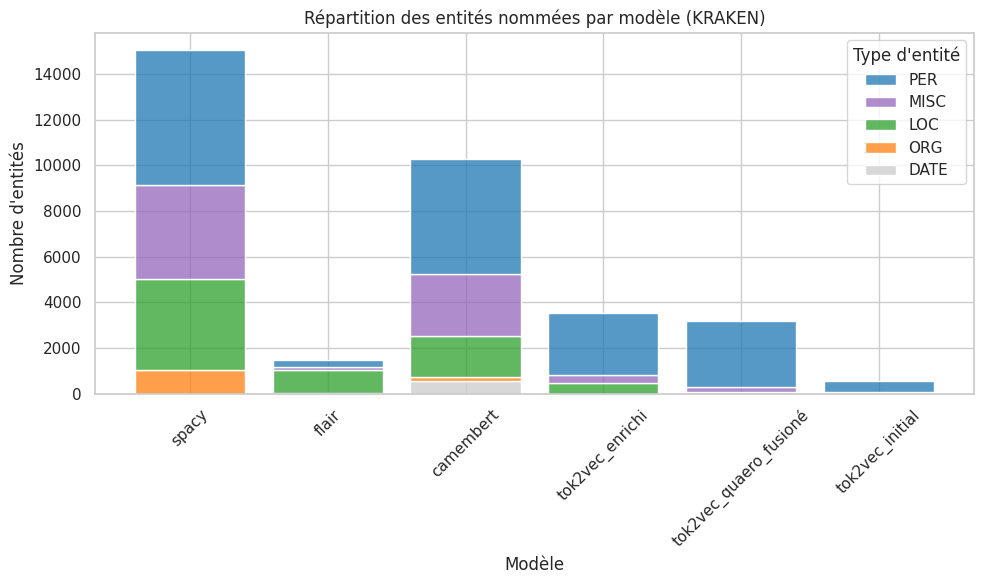

In [ ]:
entite_colors = {
    "PER": "#1f77b4",
    "LOC": "#2ca02c",
    "ORG": "#ff7f0e",
    "MISC": (148/255, 103/255, 189/255, 0.5),
    "DATE": "#cccccc"
}

for source in fichiers:
    df = []

    for modele, path in fichiers[source].items():
        cpt = compter_par_type(path)
        for entite, nb in cpt.items():
            label = normaliser_label(entite)
            df.append({
                "Modèle": modele,
                "Type d'entité": label,
                "Nombre": nb
            })

    df_plot = pd.DataFrame(df)

    plt.figure(figsize=(10, 6))
    sns.histplot(
        data=df_plot,
        x="Modèle",
        weights="Nombre",
        hue="Type d'entité",
        multiple="stack",
        palette=entite_colors,
        shrink=0.8
    )

    plt.title(f"Répartition des entités nommées par modèle ({source})")
    plt.ylabel("Nombre d'entités")
    plt.xticks(rotation=45)
    plt.tight_layout()

    output_path = os.path.join(base_path, f"stacked_entities_{source}.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()